# Set up timeGPT client

In [1]:
from nixtla import NixtlaClient

In [2]:
with open('api_key') as file:
    BGformer_key = file.read()

nixtla_client = NixtlaClient(api_key = BGformer_key)

In [3]:
nixtla_client.validate_api_key()

INFO:nixtla.nixtla_client:Happy Forecasting! :), If you have questions or need support, please email ops@nixtla.io


True

# Prediction

## Read data

In [4]:
import pathlib
from utils import dataloader, connect_gt_and_pred, calculate_error_distributions

In [16]:
config = {
    # model types: NHITS, TimesNet, FEDformer, Informer, Autoformer, iTransformer
    'models': [nixtla_client],
    # datasets: ICU, Ohio
    'train_dataset': 'ICU_train',
    'test_dataset': 'ICU_test',
    'normalize': False,
    'TN_topk': 4,
    'max_steps': 1000,
    'val_check_steps': 500,
    'horizon': 3,
    'snippet_length': 24,
    'enable_checkpointing': True,
}

snippet_length = config['snippet_length']
horizon = config['horizon']

In [17]:
data = dataloader(config=config, train=False, basepath=pathlib.PureWindowsPath('D:\Developer\BGformer'))
Y_df = data.find_all_continuous_snippets(hours=config['snippet_length'])
models_array = [nixtla_client]

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\msz30\AppData\Local\Temp\ipykernel_16948\1806969556.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = dataloader(config=config, train=False, basepath=pathlib.PureWindowsPath('D:\Developer\BGformer'))


16931


In [ ]:
len(Y_df)

In [18]:
# drop last horizon length y values for prediction
ids_to_drop = [i for i in range(len(Y_df)) if i % snippet_length >= snippet_length-horizon]
ids_to_drop_for_comparison = [i for i in range(len(Y_df)) if i % snippet_length < snippet_length-horizon]

Y_df_gt_window = Y_df.drop(ids_to_drop)
Y_df_gt_horizon = Y_df.drop(ids_to_drop_for_comparison)

Y_df_gt_window.head()

,idx,y,insulin_milliUnit - last 3 hours,carbs_milliGramm,SI,ds,unique_id
0,4.0,12.562264,4000.0,4824.0,0.000000,2020-01-01 00:00:00,cef6-01_01_0
1,4.0,13.248780,10000.0,4824.0,0.000003,2020-01-01 01:00:00,cef6-01_01_0
2,4.0,13.029268,10000.0,4824.0,0.000035,2020-01-01 02:00:00,cef6-01_01_0
3,4.0,12.338182,12000.0,4824.0,0.000056,2020-01-01 03:00:00,cef6-01_01_0
4,4.0,12.225000,12000.0,4824.0,0.000043,2020-01-01 04:00:00,cef6-01_01_0


In [19]:
# predict
# Y_hat_df_2 = nixtla_client.forecast(df=Y_df_gt_window, h=horizon, finetune_steps=20, finetune_loss="rmse")

# Y_df_gt_window.drop(columns=['insulin_milliUnit - last 3 hours', 'carbs_milliGramm', 'SI', 'idx'], inplace=True)
Y_hat_df_2 = nixtla_client.forecast(df=Y_df_gt_window, h=horizon, clean_ex_first=True)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: h
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using historical exogenous features: ['idx', 'insulin_milliUnit - last 3 hours', 'carbs_milliGramm', 'SI']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


In [20]:
Y_hat_df_2.to_csv('results/TimeGTP_24-3.csv')

In [12]:
from statsforecast import StatsForecast

In [22]:
df_to_plot_2 = connect_gt_and_pred(df_gt=Y_df, df_pred=Y_hat_df_2, snippet_length=snippet_length, horizon=horizon)

Started merging function
Cutoff timestamps appended


100%|██████████| 50793/50793 [00:27<00:00, 1870.37it/s]
c:\Program Files\Anaconda3\envs\timeGPT\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)






  Model name Statistic       t+1       t+2       t+3
0    TimeGPT      Mean  0.047932  0.048214  0.051636
1    TimeGPT       Std  0.318256  0.314614  0.313346


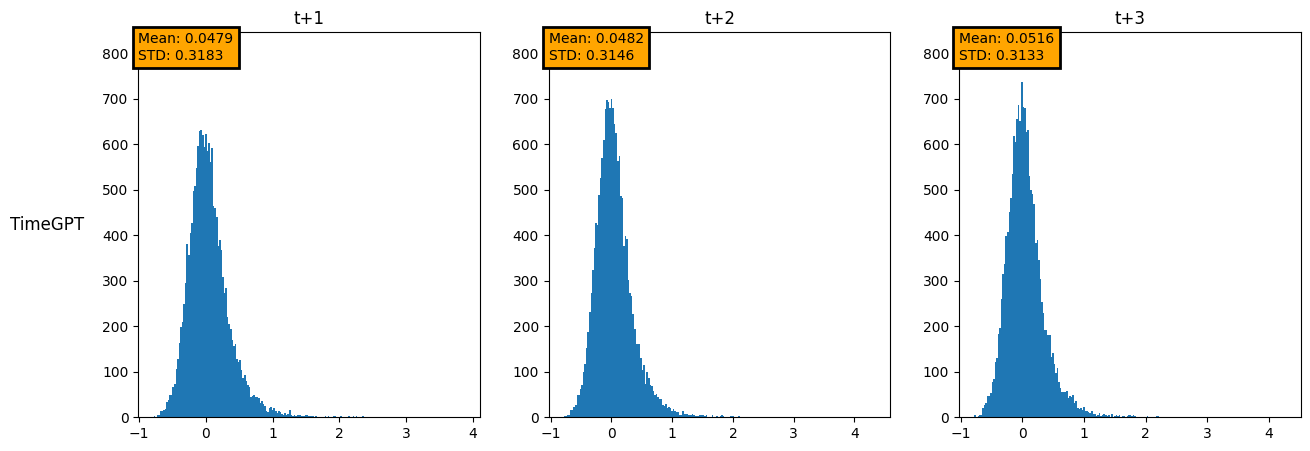

In [23]:
prediction_graphs = StatsForecast.plot(Y_df, df_to_plot_2.drop(columns=['y', 'cutoff']), max_insample_length=1260)
histograms, means_stds_df = calculate_error_distributions(Y_df_gt_horizon, Y_hat_df_2, models='TimeGPT', horizon=horizon)

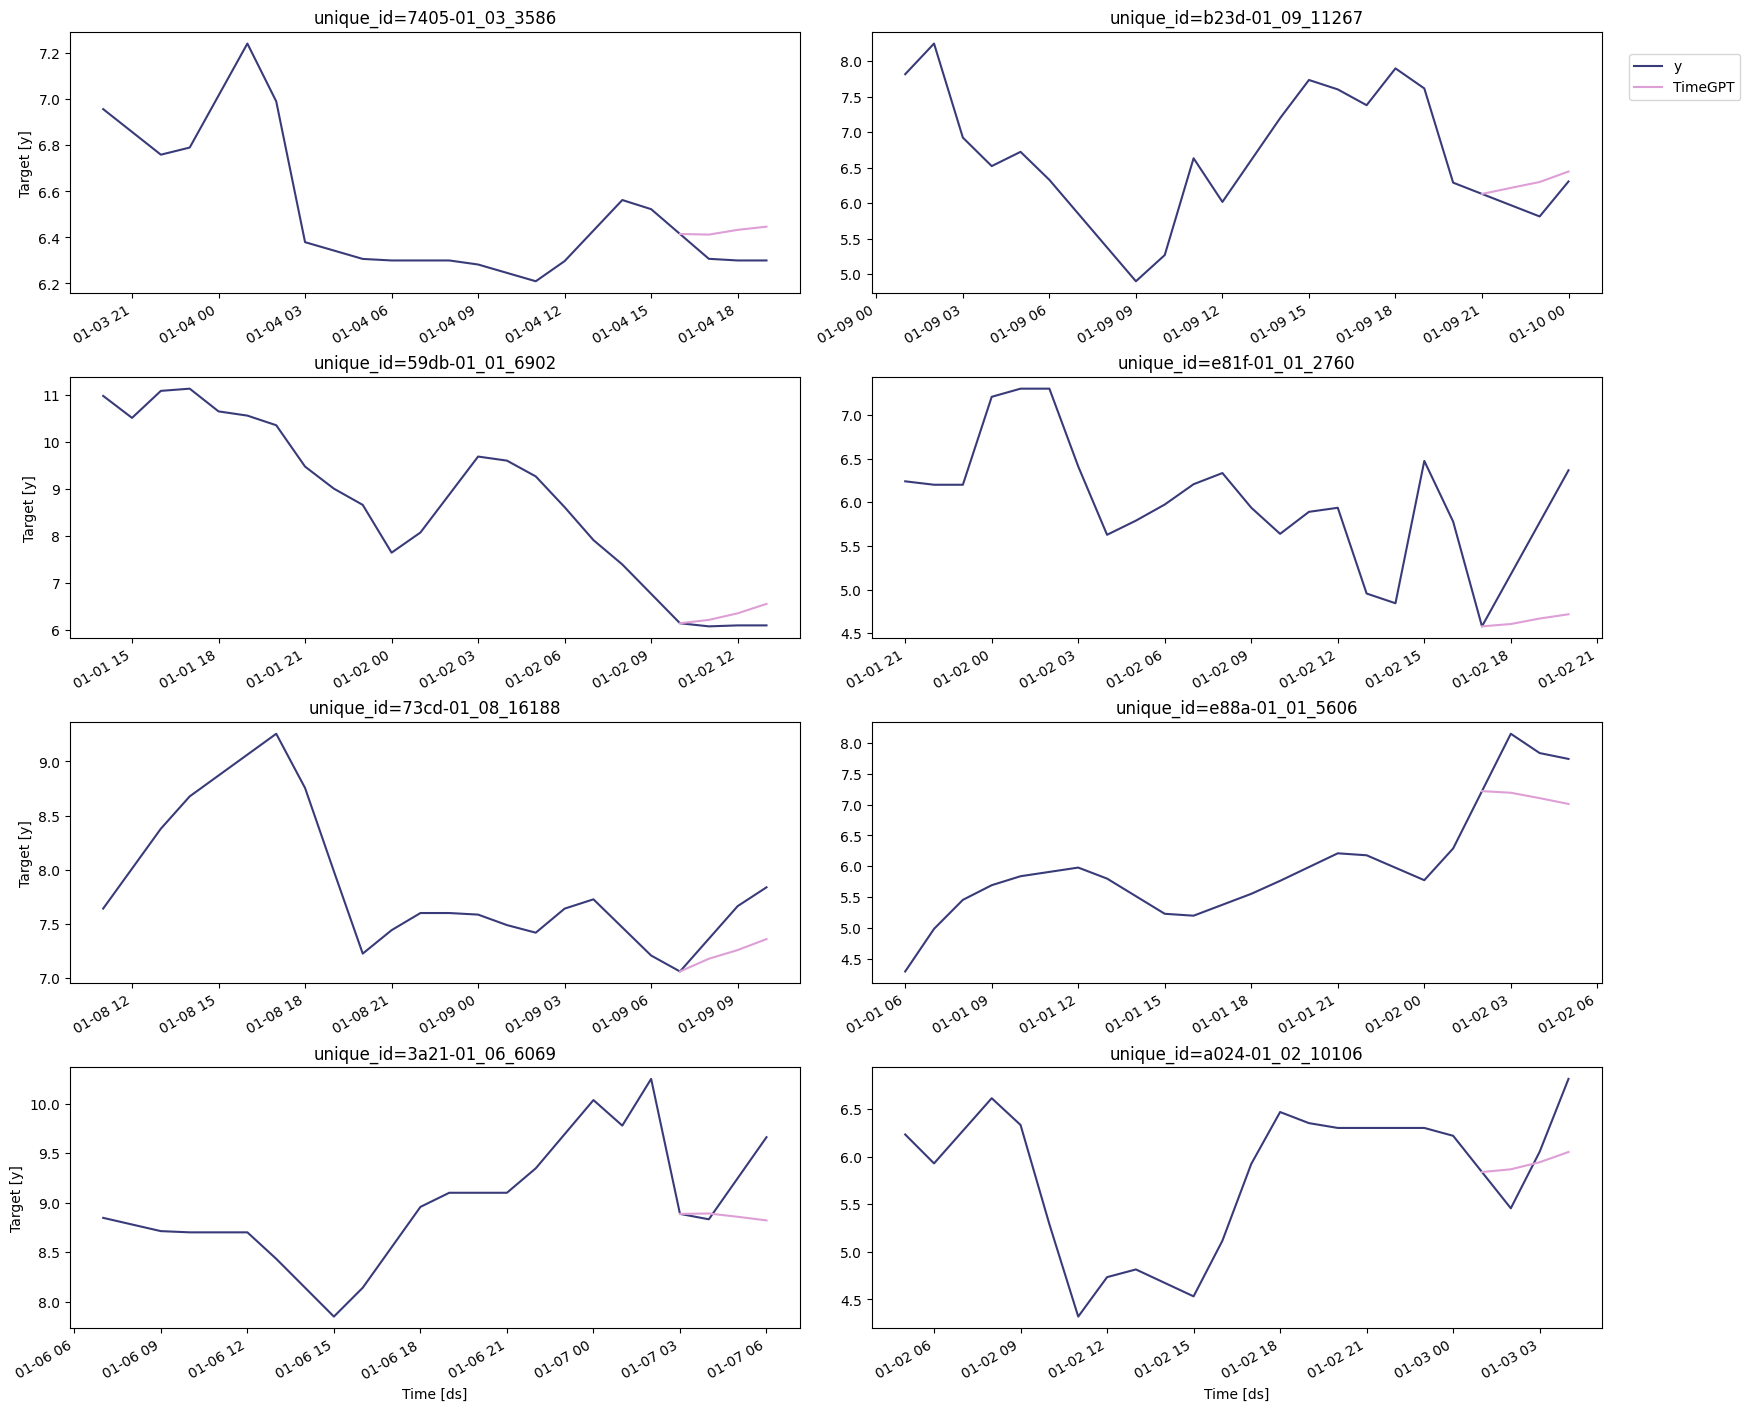

In [24]:
prediction_graphs